# Compare the different implementations of the same model

Testing metrics and "model_based_ness" (amount of context retrieval during rollout) with
python model.

Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

Import local moduls

In [2]:
from ego_revaluation import run_original
from ego_revaluation.config import defaults

In [3]:
DOT_PRODUCT = 'dot_product'
COSINE_SIMILARITY = 'cosine_similarity'

metric = COSINE_SIMILARITY
model_based_ness = 0.

data = run_original.run(500, metric=metric, model_based_ness=model_based_ness)

*** Reward Estimation ***
** Baseline **
    State 1: 9.999740880070963    (Real: 10)
    State 2: 1.0161883551144848    (Real: 1)
** Reward Revaluation **
    State 1: 3.1432474591390482    (Real: 1)
    State 2: 7.861693619301629    (Real: 10)
** Transition Revaluation **
    State 1: 3.268033642794484    (Real: 1)
    State 2: 7.328488929894165    (Real: 10)
*** Reward Revaluation (scaled) ***
  Mean = 13.7025
  SEM  = 0.0887

Transition revaluation:
  Mean = 13.0435
  SEM  = 0.1800


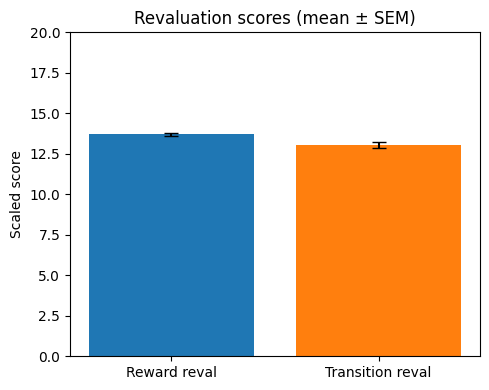

In [5]:
condition = f'IR={defaults.STATE_INTEGRATION_RATE}_TIME={defaults.TIME_RETRIEVAL_WEIGHT}'

PATH = f"reward_vs_transition_reval_{condition}.pdf"

# Model data
reval_scores_reward = np.array(data['reval_scores_reward'])
reval_scores_transition = np.array(data['reval_scores_transition'])

# get scaling factor: scale reward_reval to .5199
scaling_factor = 1  # / reval_scores_reward.mean()

# scale data
rs_reward_scaled = reval_scores_reward * scaling_factor
rs_transition_scaled = reval_scores_transition * scaling_factor

# Means
means = [
    rs_reward_scaled.mean(),
    rs_transition_scaled.mean()
]

# SEMs
sems = [
    rs_reward_scaled.std(ddof=1) / np.sqrt(len(rs_reward_scaled)),
    rs_transition_scaled.std(ddof=1) / np.sqrt(len(rs_transition_scaled))
]

# Estimated Rewards
er_baseline_1 = np.array(data['estimated_reward_state_1_baseline']).mean()
er_baseline_2 = np.array(data['estimated_reward_state_2_baseline']).mean()
er_reward_reval_1 = np.array(data['estimated_reward_state_1_reward_reval']).mean()
er_reward_reval_2 = np.array(data['estimated_reward_state_2_reward_reval']).mean()
er_transition_reval_1 = np.array(data['estimated_reward_state_1_transition_reval']).mean()
er_transition_reval_2 = np.array(data['estimated_reward_state_2_transition_reval']).mean()

print("*** Reward Estimation ***")
print("** Baseline **")
print(f"    State 1: {er_baseline_1}    (Real: {defaults.REWARD_BASELINE_1})")
print(f"    State 2: {er_baseline_2}    (Real: {defaults.REWARD_BASELINE_2})")
print('** Reward Revaluation **')
print(f"    State 1: {er_reward_reval_1}    (Real: {defaults.REWARD_BASELINE_2})")
print(f"    State 2: {er_reward_reval_2}    (Real: {defaults.REWARD_BASELINE_1})")
print('** Transition Revaluation **')
print(f"    State 1: {er_transition_reval_1}    (Real: {defaults.REWARD_BASELINE_2})")
print(f"    State 2: {er_transition_reval_2}    (Real: {defaults.REWARD_BASELINE_1})")

print("*** Reward Revaluation (scaled) ***")
print(f"  Mean = {means[0]:.4f}")
print(f"  SEM  = {sems[0]:.4f}")

print("\nTransition revaluation:")
print(f"  Mean = {means[1]:.4f}")
print(f"  SEM  = {sems[1]:.4f}")

# Plot
plt.figure(figsize=(5, 4))
x = np.arange(2)
labels = ["Reward reval", "Transition reval"]

plt.bar(x, means, yerr=sems, capsize=5,
        color=["tab:blue", "tab:orange"])

plt.xticks(x, labels)
plt.ylabel("Scaled score")
plt.ylim(0, 20)

plt.title("Revaluation scores (mean ± SEM)")
plt.tight_layout()
plt.savefig(PATH)
# plt.show()


  SEM  = 0.0000


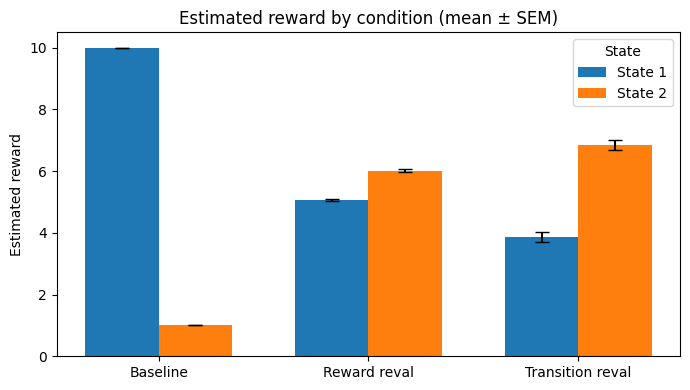

In [5]:
# Model data
estimated_state_1_bl = np.array(data['estimated_reward_state_1_baseline'])
estimated_state_2_bl = np.array(data['estimated_reward_state_2_baseline'])

estimated_state_1_rr = np.array(data['estimated_reward_state_1_reward_reval'])
estimated_state_2_rr = np.array(data['estimated_reward_state_2_reward_reval'])

estimated_state_1_tr = np.array(data['estimated_reward_state_1_transition_reval'])
estimated_state_2_tr = np.array(data['estimated_reward_state_2_transition_reval'])


# get scaling factor: scale reward_reval to .5199
scaling_factor = 1. #.5199 / reval_scores_reward.mean()

# scale data
rs_reward_scaled = reval_scores_reward * scaling_factor
rs_transition_scaled = reval_scores_transition * scaling_factor

# Means
means = [
estimated_state_1_bl.mean(),
estimated_state_2_bl.mean(),

estimated_state_1_rr.mean(),
estimated_state_2_rr.mean(),

estimated_state_1_tr.mean(),
estimated_state_2_tr.mean(),
]

# SEMs
sems = [
estimated_state_1_bl.std(ddof=1)/ np.sqrt(len(estimated_state_1_bl)),
estimated_state_2_bl.std(ddof=1)/ np.sqrt(len(estimated_state_2_bl)),
estimated_state_1_rr.std(ddof=1)/ np.sqrt(len(estimated_state_1_rr)),
estimated_state_2_rr.std(ddof=1)/ np.sqrt(len(estimated_state_2_rr)),
estimated_state_1_tr.std(ddof=1)/ np.sqrt(len(estimated_state_1_tr)),
estimated_state_2_tr.std(ddof=1)/ np.sqrt(len(estimated_state_2_tr)),
]

# Estimated Rewards
print(f"  SEM  = {sems[1]:.4f}")
# --- GROUPED BAR PLOT: 3 groups × 2 bars ---

plt.figure(figsize=(7, 4))

# means = [bl_s1, bl_s2, rr_s1, rr_s2, tr_s1, tr_s2]
# sems  = [   same order   ]

means = np.array(means).reshape(3, 2)    # shape (3 groups, 2 bars each)
sems  = np.array(sems).reshape(3, 2)

group_names = ["Baseline", "Reward reval", "Transition reval"]
bar_names   = ["State 1", "State 2"]

x = np.arange(3)  # 3 groups
width = 0.35

plt.bar(x - width/2, means[:, 0], width, yerr=sems[:, 0], capsize=5, label="State 1")
plt.bar(x + width/2, means[:, 1], width, yerr=sems[:, 1], capsize=5, label="State 2")

plt.xticks(x, group_names)
plt.ylabel("Estimated reward")
plt.title("Estimated reward by condition (mean ± SEM)")

plt.legend(title="State")

plt.tight_layout()
plt.savefig(f"reward_vs_transition_reval_python_non_flipped_{model_based_ness}_{metric}.pdf")
#plt.savefig(f"reward_vs_transition_reval_python_{model_based_ness}_{metric}.pdf")
plt.show()

# plt.show()

In [ ]:

plot_data = pd.DataFrame(revaluation_scores[:,:2],columns=['Reward<br>Revaluation','Transition<br>Revaluation']).melt(var_name='Condition',value_name='Revaluation Score')
scaling_factor = .5199/revaluation_scores[:,0].mean() # Scale revaluation scores to match mean of behavioral data
t_test_results = pg.pairwise_tests(plot_data,between='Condition',dv='Revaluation Score')

plot_data['Revaluation Score'] *= scaling_factor
plot_data = plot_data.groupby(['Condition']).agg(**{'Revaluation Score': ('Revaluation Score','mean'), 'error': ('Revaluation Score','sem')}).reset_index()
fig = px.bar(plot_data,range_y=[0,1],x='Condition',y='Revaluation Score',color='Condition',error_y='error',
             color_discrete_sequence=['#0099C6','#FF9900'],title='Model Performance')
fig.update_layout(showlegend=False)
fig.show()